# Propagación de restricciones

La idea detrás de esto es poder **mejorar cotas** actuales. Supongamos que se tiene la siguiente restricción, donde $C^+$ son los coeficientes positivos y $C^-$ aquellos negativos:

$$\sum_{j\in C^+}a_jx_j+\sum_{j\in C^-}a_jx_j\leq b$$ 

Si cada variable $x_j$ tiene cotas del estilo $l_j\leq x_j\leq u_j$, entonces podemos definirnos la actividad mínima y máxima:

$$
\begin{aligned}
\underline{\alpha}&=\sum_{j\in C^+}a_jl_j+\sum_{j\in C^-}a_ju_j\\ \\
\bar{\alpha}&=\sum_{j\in C^+}a_ju_j+\sum_{j\in C^-}a_jl_j
\end{aligned}
$$

Con esto, obtenemos nuevas cotas implicadas:

$$
\begin{aligned}
\bar{u_j}&\leq l_j+\frac{b-\alpha_\min}{a_j}\\ \\
\bar{l_j}&\geq u_j+\frac{b-\underline{\alpha}}{a_j}
\end{aligned}
$$

#### Ejemplo

Supongamos que tenemos las variables $x_1, x_2 \in [0,6]$, sujetas a las siguientes restricciones: 

$$2x_1+3x_2\leq 10$$

La actividad mínima llegaría a ser $0$ al reemplazar $2(0)+3(0) = 0$ y la máxima sería $2(6) + 3(6) = 30$. Por lo tanto, se tienen las nuevas cotas actualizadas:

- Para $x_1$:

$$u_j = l_j+\frac{b-\alpha_\min}{a_j} = 0 + \frac{10 - 0}{2} = 5$$

- Para $x_2$:

$$u_j = l_j+\frac{b-\alpha_\min}{a_j} = 0 + \frac{10 - 0}{3} = 3.33$$

Así, las nuevas cotas son $x_1\in [0,5]$ y $x_2\in [0,3.33]$. 

Notemos que esto como tal **no es una heurística**. Esto se puede aplicar en una etapa anterior como *presolve*. 

## Fix and propagate

Es una heurística para encontrar soluciones enteras factibles. Simplemente tomamos la solución actual y fijamos algunas coordenadas. A partir de las coordenadas fijas intentamos propagar esas fijaciones por las restricciones para eliminar o acotar valores. Si una variable queda acotada con un único valor posible, también se fija y se sigue propagando. En caso de infactibilidad, se hace un backtrack para deshacer el cambio.

#### Ejemplo

Supongamos que tenemos el siguiente problema 

$$
\begin{aligned}
2x_1+3x_2&\leq 10\\ \\
x_1+x_2&\geq 4\\ \\
x_1,x_2&\in\mathbb{Z}_{\geq 0}
\end{aligned}
$$

Con una solución propuesta de $(3.2, 1.6)$. Por lo tanto, fijemos $x_1$ a $3$ ya que es casi entero. Esto sería el **fix**. A partir de aquello, obtendriamos el siguiente poliedro:

$$
\begin{aligned}
x_2&\leq 4/3 \\ \\
x_2&\geq 1
\end{aligned}
$$

Así, podemos redondear $x_2$ a $1$ y obtendriamos una solución factible entera.

A continuación un pequeño código que hace el Fix and Propagate

In [31]:
import math

import gurobipy as gp
from gurobipy import GRB


def build_var_index(xvars):
    """Mapa var.index -> posición en xvars (O(1))."""
    return {v.index: i for i, v in enumerate(xvars)}


def cache_linear_rows_for(xvars, var_to_pos, model):
    """
    Extrae filas lineales relevantes a xvars.
    Devuelve: lista de (idxs, coeffs, sense, rhs).
    """
    rows = []
    for c in model.getConstrs():
        row = model.getRow(c)
        rhs = c.RHS
        sense = c.Sense  # '<', '>', '='
        idxs, coeffs = [], []
        for k in range(row.size()):
            v = row.getVar(k)
            pos = var_to_pos.get(v.index)
            if pos is not None:
                idxs.append(pos)
                coeffs.append(row.getCoeff(k))
        if idxs:
            rows.append((idxs, coeffs, sense, rhs))
    return rows

In [32]:
def fix_and_propagate(
    x_rel, rows, lbs, ubs, vtypes, int_eps=1e-6, feas_tol=1e-6, max_iters=1000
):
    """
    FIX: fija variables 'casi enteras' según x_rel.
    PROPAGATE: aplica propagación de restricciones lineales para estrechar bounds.
    Repite hasta alcanzar un punto fijo o detectar contradicción.

    Parámetros:
      x_rel    : lista/array con la solución LP del nodo (orden xvars).
      rows     : [(idxs, coeffs, sense, rhs)] como en cache_linear_rows_for.
      lbs, ubs : bounds originales por variable (list[float]).
      vtypes   : tipos ('B','I','C') por variable.

    Devuelve:
      y : lista de valores (enteros para B/I, real para C) si factible, o None si falla.
    """
    n = len(x_rel)
    # Copias de trabajo de bounds
    L = [float(lbs[j]) for j in range(n)]
    U = [float(ubs[j]) for j in range(n)]

    # FIX inicial por cercanía a enteros
    for j in range(n):
        if vtypes[j] in (GRB.BINARY, GRB.INTEGER):
            r = round(x_rel[j])
            if abs(x_rel[j] - r) <= int_eps:
                L[j] = U[j] = float(r)
            elif vtypes[j] == GRB.BINARY:
                # umbral estándar 0.5 si no está cerca de entero
                L[j] = max(L[j], 0.0)
                U[j] = min(U[j], 1.0)

    # Ciclo de propagación
    changed = True
    iters = 0
    while changed and iters < max_iters:
        changed = False
        iters += 1

        for idxs, coeffs, sense, rhs in rows:
            # Normaliza: para '>': multiplica por -1 (lo convierte en '<')
            if sense == ">":
                aj = [-a for a in coeffs]
                b = -rhs
                s = "<"
            else:
                aj = list(coeffs)
                b = rhs
                s = sense  # '<' o '='

            # Para '=' aplicamos dos veces: como '<' y como '>':
            senses_to_apply = ["<"] if s == "<" else ["<", ">"]

            for mode in senses_to_apply:
                if mode == ">":
                    # aplicar a -a x <= -b
                    a = [-a for a in aj]
                    bb = -b
                else:
                    a = aj
                    bb = b

                # Partición por signo
                C_pos = []
                C_neg = []
                for t, a_j in enumerate(a):
                    if a_j > 0:
                        C_pos.append(t)
                    elif a_j < 0:
                        C_neg.append(t)

                # Actividad mínima y máxima para esta fila
                # alpha_min = sum_{a>0} a * L + sum_{a<0} a * U
                # alpha_max = sum_{a>0} a * U + sum_{a<0} a * L
                alpha_min = 0.0
                alpha_max = 0.0
                for t in C_pos:
                    j = idxs[t]
                    alpha_min += a[t] * L[j]
                    alpha_max += a[t] * U[j]
                for t in C_neg:
                    j = idxs[t]
                    alpha_min += a[t] * U[j]
                    alpha_max += a[t] * L[j]

                # Si ni siquiera alpha_min <= bb, la fila ya es infactible
                if alpha_min > bb + feas_tol:
                    return None

                # Propagación por variable (sólo si a_j != 0)
                for t in range(len(a)):
                    a_j = a[t]
                    if abs(a_j) <= 0.0:
                        continue
                    j = idxs[t]

                    if a_j > 0:
                        # u_j <= l_j + (b - αmin) / a_j
                        new_U = min(U[j], L[j] + (bb - alpha_min) / a_j)
                        if vtypes[j] in (GRB.BINARY, GRB.INTEGER):
                            new_U = math.floor(new_U + 1e-12)  # enteriza techo
                        if new_U < U[j] - 1e-12:
                            U[j] = new_U
                            changed = True
                    else:
                        # l_j >= u_j + (b - αmax) / a_j   (nota: a_j < 0)
                        new_L = max(L[j], U[j] + (bb - alpha_max) / a_j)
                        if vtypes[j] in (GRB.BINARY, GRB.INTEGER):
                            new_L = math.ceil(new_L - 1e-12)  # enteriza piso
                        if new_L > L[j] + 1e-12:
                            L[j] = new_L
                            changed = True

                    # Contradicción local
                    if L[j] > U[j] + feas_tol:
                        return None

                # **Fijación por dominio unitario**
                for t in range(len(a)):
                    j = idxs[t]
                    if vtypes[j] in (GRB.BINARY, GRB.INTEGER):
                        if abs(U[j] - L[j]) <= 1e-12:
                            # fija duro al entero más cercano dentro de bounds
                            val = float(round(L[j]))
                            L[j] = U[j] = val

    # Construye y verifica una solución candidata
    y = [0.0] * n
    for j in range(n):
        if vtypes[j] == GRB.BINARY:
            if abs(U[j] - L[j]) <= 1e-12:
                y[j] = float(int(round(L[j])))
            else:
                # fallback: elige el extremo que respete más filas (tomamos L)
                y[j] = float(int(round(L[j])))
            # clip
            y[j] = min(max(y[j], lbs[j]), ubs[j])
        elif vtypes[j] == GRB.INTEGER:
            val = L[j] if abs(U[j] - L[j]) <= 1e-12 else round(x_rel[j])
            y[j] = float(int(val))
            y[j] = min(max(y[j], math.ceil(lbs[j])), math.floor(ubs[j]))
        else:
            # continuas: deja x_rel truncada a bounds actualizados
            val = min(max(x_rel[j], L[j]), U[j])
            y[j] = float(val)

    # Chequeo rápido de filas
    for idxs, coeffs, sense, rhs in rows:
        s = sense
        a = coeffs
        b = rhs
        val = sum(a[t] * y[idxs[t]] for t in range(len(a)))
        if s == "<" and val > b + feas_tol:
            return None
        if s == ">" and val < b - feas_tol:
            return None
        if s == "=" and abs(val - b) > feas_tol:
            return None

    # Verificamos que todo esté bien..
    for j in range(n):
        if vtypes[j] == GRB.BINARY and y[j] not in (0.0, 1.0):
            return None
        if vtypes[j] == GRB.INTEGER and abs(y[j] - round(y[j])) > 1e-8:
            return None
        if y[j] < lbs[j] - 1e-9 or y[j] > ubs[j] + 1e-9:
            return None

    return y

Y, nos definimos una función tipo "main" para definir el callback.

In [33]:
def make_fixprop_callback(model, xvars, int_eps=1e-6, feas_tol=1e-6):
    model.update()
    var_to_pos = build_var_index(xvars)
    rows = cache_linear_rows_for(xvars, var_to_pos, model)
    lbs = [float(v.lb) if v.lb != -GRB.INFINITY else -1e100 for v in xvars]
    ubs = [float(v.ub) if v.ub != GRB.INFINITY else 1e100 for v in xvars]
    vtypes = [v.VType for v in xvars]

    def cb(cb_model, where):

        if where == GRB.Callback.MIP:
            nodes = model.cbGet(GRB.Callback.MIP_NODCNT)
            bestbd = model.cbGet(GRB.Callback.MIP_OBJBND)  # "best bound"
            bestst = model.cbGet(GRB.Callback.MIP_OBJBST)  # "best incumbent"

            # Detectar sentido: +1=minimiza, -1=maximiza
            sense = model.ModelSense

            if sense == -1:  # MAXIMIZAR
                LB, UB = bestst, bestbd  # inc es LB; bound es UB
            else:  # MINIMIZAR
                LB, UB = bestbd, bestst  # bound es LB; inc es UB

            model._nodes_hist.append(nodes)
            model._lb_hist.append(LB)
            model._ub_hist.append(UB)

        elif where != GRB.Callback.MIPNODE:
            return
        try:
            status = cb_model.cbGet(GRB.Callback.MIPNODE_STATUS)
            if status != GRB.OPTIMAL:
                return
            # solución LP del nodo
            x_rel = cb_model.cbGetNodeRel(xvars)

            # Fix & Propagate
            y = fix_and_propagate(
                x_rel, rows, lbs, ubs, vtypes, int_eps=int_eps, feas_tol=feas_tol
            )
            if y is not None:
                cb_model.cbSetSolution(xvars, y)
                print("Fix&Propagate: propuesta de solución")
        except gp.GurobiError:
            return

    return cb

Para verlo, probemos en una instancia del knapsack problem.

In [36]:
import gurobipy as gp
import numpy as np
from gurobipy import GRB

from helpers import instancia_knapsack


def crearModelo(nombre):
    m = gp.Model(nombre)

    params = {
        # === DESACTIVAR COSAS ===
        "Heuristics": 0.0,  # 0 desactiva heurísticas internas
        "Cuts": 0,  # 0 desactiva cortes
        "Presolve": 0,  # 0 desactiva presolve (2 agresivo, -1 auto)
        "Symmetry": 0,  # 0 desactiva detección de simetría
        "ConcurrentMIP": 1,  # 1 desactiva concurrente (corre estrategias distintas en paralelo)
        # === FOCO DE BÚSQUEDA ===
        "MIPFocus": 0,  # 0 auto, 1 incumbente rápido, 2 gap, 3 bound
        "VarBranch": 0,  # 0 auto, 1 max infeas, 2 pseudo cost; como se elige la variable actual para hacer branching
        "NodeMethod": 1,  # 1 dual simplex en nodos (0 auto, 2 barrier); como se resuelve el LP en los nodos
        "BranchDir": 0,  # 0 auto, 1 up, -1 down
        # === TOLERANCIAS ===
        "MIPGap": 0.0,  # gap objetivo relativo deseado (p.ej. 0.01 = 1%)
        "FeasibilityTol": 1e-6,  # tolerancia de viabilidad
        "IntFeasTol": 1e-5,  # tolerancia de integralidad
        "NumericFocus": 0,  # 0-3 (3 = más robusto numéricamente)
        # === LÍMITES Y LOG ===
        "TimeLimit": 60,  # seg. (0 = sin límite)
        "BestObjStop": None,  # para minimización: detiene al llegar a obj <= valor
        "BestBdStop": None,  # detiene si bound <= valor
        "Threads": 0,  # 0 = auto
        "Seed": 42,
        "LogToConsole": 1,  # 1 muestra log, 0 oculta
    }

    for k, v in params.items():
        if v is not None:
            m.setParam(k, v)
    return m


m = crearModelo("Auxiliar 7")

N = 1000
M = 2

v, W, caps = instancia_knapsack(
    n=N, m=M, density=0.56, seed=42, pesos_chicos=True
)  # density más baja = más difícil

x = m.addVars(N, vtype=GRB.BINARY, name="x")


# Objetivo: maximizar valor
m.setObjective(sum(v[i] * x[i] for i in range(N)), GRB.MAXIMIZE)

for j in range(len(caps)):
    m.addConstr(sum(W[j][i] * x[i] for i in range(N)) <= caps[j], name=f"cap_{j}")

# Atributos para callback
m._x = [x[i] for i in range(N)]
m._v = v
m._W = W
m._caps = caps
m._nodes_hist, m._ub_hist, m._lb_hist = [], [], []

m.update()
cb = make_fixprop_callback(m, m._x, int_eps=1e-6, feas_tol=1e-6)
m.optimize(cb)

Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Symmetry to value 0
Set parameter ConcurrentMIP to value 1
Set parameter MIPFocus to value 0
Set parameter VarBranch to value 0
Set parameter NodeMethod to value 1
Set parameter BranchDir to value 0
Set parameter MIPGap to value 0
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-05
Set parameter NumericFocus to value 0
Set parameter TimeLimit to value 60
Set parameter Threads to value 0
Set parameter Seed to value 42
Set parameter LogToConsole to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0
NodeMethod  1
Symmetry  0
VarBranch  0
Cuts  0
Presolve  0
Seed  42

Optimize a model with 2 rows, 1000 columns and 2000 nonzeros
Model fingerpr

/var/folders/kg/_zd3ll1x7zz9vkxv49rq_m9m0000gn/T/ipykernel_9893/1791438594.py:5: RuntimeWarning: invalid value encountered in log
  plt.plot(m._nodes_hist[2:], np.log(m._lb_hist[2:]), label="LB", marker="o")


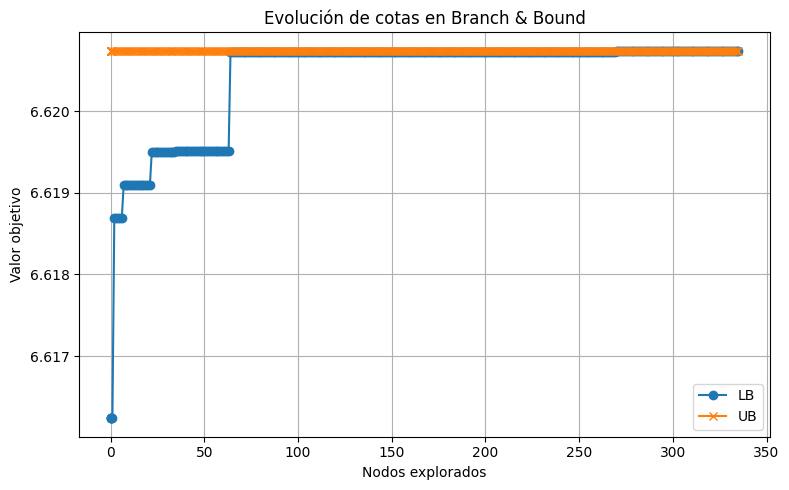

In [35]:
import matplotlib.pyplot as plt

# Gráfico de UB y LB
plt.figure(figsize=(8, 5))
plt.plot(m._nodes_hist[2:], np.log(m._lb_hist[2:]), label="LB", marker="o")
plt.plot(m._nodes_hist[2:], np.log(m._ub_hist[2:]), label="UB", marker="x")
plt.xlabel("Nodos explorados")
plt.ylabel("Valor objetivo")
plt.title("Evolución de cotas en Branch & Bound")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Diving 

Es una mezcla de *fix-and-propagate*, donde vamos resolviendo LP's entre medio tras ir fijando variables. 

La idea central es *"bucear"* (*"tirarse un piquero"*) hacia una región del espacio donde las variables LP se vuelven enteras, guiándose por la estructura y los valores fraccionales actuales. 

1. **Comenzar de la solución LP actual**.

2. **Identificar las variables fraccionales**: Construimos el conjunto

$$
F=\lbrace j\in\mathcal{I}\;\mid\;\bar{x}_j\;\notin\;\mathbb{Z}\rbrace
$$

3. **Selecciona una variable para fijar**: Escogemos $x_j$ según algún criterio, por ejemplo, menos locks, menos fraccionaría, la variable con mejor pseudocostos, etc.

4. **Propagar restricciones**

5. **Resolver el LP reducido**

6. **Repetir** hasta obtener una solución entera.


#### Ejemplo

Consideremos el siguiente problema MIP binario: 

$$
\begin{aligned}
\max & \quad 6x_1 + 4x_2 + 5x_3 \\ \\
\text{s.a.} & \quad 3x_1 + 2x_2 + 4x_3 \le 6, \\ \\
& \quad x_1 + x_2 \le 1, \\ \\
& \quad x_i \in \{0,1\}.
\end{aligned}
$$

Al relajar la restricción entera, obtenemos como solución $\bar{x}=(1, 0.5, 0.625)$. Intentemos fijar $x_3=1$ (por algún criterio heurístico o arbitrario). Sustituyendolo en las restricciones, tenemos lo siguiente: 

$$
\begin{aligned}
3x_1 + 2x_2 + 4(1) &\rightarrow 3x_1 + 2x_2 \leq 2\\ \\
x_1 + x_2 &\leq 1
\end{aligned}
$$

De la primera restricción, se llega que $x_1\neq 1$, de lo contrario, se llegaría a una infactibilidad. Por lo tanto, propagando restricciones, llegamos que $x_1=0$. Así, del problema propagado llegamos a un problema con $x_1 = 0$ y $x_3 = 1$. El modelo reducido llegaría a tener una variable, cuya solución llegaría a ser $x_2 = 1$.

De tal forma, tendríamos como solución $\vec{x} = (0, 1, 1)$

Lamentablemente, los callbacks no permiten (o facilitan) el proceso de resolver el LP específico. Es decir, dentro de `MIPNODE` no podemos reoptimizar el LP. El motivo técnico es que durante un callback, Gurobi ya está en medio de una llamada a su optimizador LP interno. Al disparar otra optimización, entrariamos en una **reentrancia** (un `optimize()` dentro de otro `optimize()`) lo que rompe el estado interno del solver.



Sin embargo, es posible hacer un script para un algoritmo de *fix-and-propagate*. En específico, la documentación de Gurobi tiene la siguiente implementación para *fix-and-dive*:

In [ ]:
#!/usr/bin/env python3.11

# Copyright 2025, Gurobi Optimization, LLC

# Implement a simple MIP heuristic.  Relax the model,
# sort variables based on fractionality, and fix the 25% of
# the fractional variables that are closest to integer variables.
# Repeat until either the relaxation is integer feasible or
# linearly infeasible.

import sys

import gurobipy as gp
from gurobipy import GRB

# Key function used to sort variables based on relaxation fractionality


def sortkey(v1):
    sol = v1.X
    return abs(sol - int(sol + 0.5))


if len(sys.argv) < 2:
    print("Usage: fixanddive.py filename")
    sys.exit(0)

# Read model

model = gp.read(sys.argv[1])

# Collect integer variables and relax them
intvars = []
for v in model.getVars():
    if v.VType != GRB.CONTINUOUS:
        intvars += [v]
        v.VType = GRB.CONTINUOUS

model.Params.OutputFlag = 0

model.optimize()


# Perform multiple iterations.  In each iteration, identify the first
# quartile of integer variables that are closest to an integer value in the
# relaxation, fix them to the nearest integer, and repeat.

for iter in range(1000):
    # create a list of fractional variables, sorted in order of increasing
    # distance from the relaxation solution to the nearest integer value

    fractional = []
    for v in intvars:
        sol = v.X
        if abs(sol - int(sol + 0.5)) > 1e-5:
            fractional += [v]

    fractional.sort(key=sortkey)

    print(f"Iteration {iter}, obj {model.ObjVal:g}, fractional {len(fractional)}")

    if len(fractional) == 0:
        print(f"Found feasible solution - objective {model.ObjVal:g}")
        break

    # Fix the first quartile to the nearest integer value
    nfix = max(int(len(fractional) / 4), 1)
    for i in range(nfix):
        v = fractional[i]
        fixval = int(v.X + 0.5)
        v.LB = fixval
        v.UB = fixval
        print(f"  Fix {v.VarName} to {fixval:g} (rel {v.X:g})")

    # Acá podriamos añadir un fix_and_propagate y convertirlo
    # en un problema de fix_and_dive
    model.optimize()

    # Check optimization result

    if model.Status != GRB.OPTIMAL:
        print("Relaxation is infeasible")
        break

# Large Neighborhood Search (LNS)

Las siguientes heurísticas consideran la búsqueda dentro del vecindario de una solución factible. Todas estas heurísticas utilizan llamadas "controladas" por un solver. Esto implica problemas desde el punto de vista del computo en callbacks: no podremos llamar la rutina `optimize()` dentro de otro `optimize()`. 

## Local Branching

Para el caso de variables binarias, definimos una vecindad alrededor del punto factible actual, de la siguiente forma:

$$\Delta (x,\tilde{x}) = \sum_{j\in\mathcal{B}\;;\;\tilde{x_j}=0}x_j+\sum_{j\in\mathcal{B}\;;\;\tilde{x_j}=1}(1-x_j)\leq k$$

Notemos que esta heurística tiene como *tradeoff* el parámetro $k$. En específico, un $k$ chico nos estaría diciendo que hay poco por explorar, mientras que un $k$ lo suficientemente grande podría llegar a significar explorar todas las combinaciones posibles. 

Para el caso general, la vecindad se llega a definir como: 

$$\sum_{j\in\mathcal{I}\;\tilde{x_j}=I_j}(x_j-l_j)+\sum_{j\in\mathcal{I}\;\tilde{x_j}=u_j}(u_j-x_j)+\sum_{j\in\mathcal{I}}(x_{j}^++x_{j}^-)\leq k$$ 

Una ventaja de esto es que se enfoca en regiones prometedoras de la solución, sin tener que explorar el árbol completo. Sin embargo, la estrategia puede llegar a atascarse si no se diversifica bien. 

In [56]:
def make_local_branching_callback(model, xvars):
    """
    - En MIPSOL: guarda el incumbente x* (vector de 0/1) en una cola para procesarlo afuera
    - En MIPNODE: si model._lb_candidate existe, intenta inyectarla con cbSetSolution
    """
    if not hasattr(model, "_lb_queue"):
        model._lb_queue = []  # cola de incumbentes x* a procesar fuera
    model._best_incumbent = None  # guarda el último incumbente visto

    def cb(cb_model, where):
        try:
            if where == GRB.Callback.MIPSOL:
                # incumbente nuevo
                xstar = cb_model.cbGetSolution(xvars)
                model._best_incumbent = xstar  # Guardamos el último incumbente visto
                # encola para local branching externo (no bloquear callback)
                model._lb_queue.append(xstar)

            elif where == GRB.Callback.MIPNODE:
                # si hay candidata externa, intenta inyectarla
                cand = getattr(model, "_lb_candidate", None)
                if cand is not None:
                    try:
                        cb_model.cbSetSolution(xvars, cand)
                    except gp.GurobiError:
                        pass
                    # limpia para no intentar inyectar en cada nodo
                    model._lb_candidate = None

        except gp.GurobiError:
            return

    return cb


# Subrutina: resolver MIP
def run_local_branching_subproblem(
    main_model, xstar, k=20, timelimit=5, threads=1, name="local_branching"
):
    """
    Crea una copia del modelo principal, agrega restricción de Local Branching
      sum_{i: x*_i=1} (1 - x_i) + sum_{i: x*_i=0} x_i <= k
    (solo para variables binarias)
    Resuelve con TimeLimit, y devuelve la lista de valores para las variables en el orden main_model._x
    Si no encuentra solución, devuelve None.
    """
    # Copia segura del modelo principal
    sub = main_model.copy()

    # Mapear variables por nombre para mantener el orden original
    sub_x = [sub.getVarByName(v.VarName) for v in main_model._x]

    # Construir LB constraint sobre las binarias
    expr = gp.LinExpr()
    bin_count = 0
    for v_sub, val in zip(sub_x, xstar):
        if v_sub.VType == GRB.BINARY:
            bin_count += 1
            expr += (1 - v_sub) if val >= 0.5 else v_sub

    if bin_count == 0:
        sub.dispose()
        return None  # no hay binarias → no aplica LB

    sub.addConstr(expr <= k, name=name)

    # Parámetros del sub-MIP
    sub.setParam("TimeLimit", timelimit)
    sub.setParam("Threads", threads)
    sub.setParam("LogToConsole", 0)

    print("Optimizando modelo del subproblema")
    sub.optimize()

    cand = None
    if sub.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and sub.SolCount > 0:
        cand = [vx.X for vx in sub_x]

    # Limpieza
    try:
        sub.dispose()
    except Exception:
        pass

    return cand


# Orquestación, funcion "main"
def local_branching_driver(
    model,
    xvars,
    k=20,
    timelimit=5,
    rounds=2,
    threads_sub=1,
    process_even_if_optimal=True,
    verbose=True,
):
    """
    Rondas:
      1) optimize() principal con callback (encola incumbentes en _lb_queue)
      2) PROCESA la cola _lb_queue aun si Status==OPTIMAL (si process_even_if_optimal=True):
           - corre sub-MIP de Local Branching (copia + restricción LB)
           - si hay candidata, setea v.Start y _lb_candidate
      3) optimize() corto para intentar inyectar la candidata
    """
    cb = make_local_branching_callback(model, xvars)

    for r in range(1, rounds + 1):
        if verbose:
            print(f"\n=== Ronda {r}/{rounds}: optimize() principal ===")
        model.optimize(cb)

        status = model.Status
        if verbose:
            print(
                f"[Driver] Status solve principal = {status} "
                f"(OPTIMAL={GRB.OPTIMAL}, INFEASIBLE={GRB.INFEASIBLE})"
            )

        # Copiamos y vaciamos la cola localmente (por si el callback vuelve a encolarse)
        queue = list(getattr(model, "_lb_queue", []))
        model._lb_queue.clear()

        if not queue:
            if verbose:
                print("[Driver] No hay incumbentes encolados tras optimize().")
            # si no hay cola y el modelo acabó óptimo/inf fact y no queremos procesar
            if status in (GRB.OPTIMAL, GRB.INFEASIBLE) and not process_even_if_optimal:
                if verbose:
                    print("[Driver] Nada que hacer; fin.")
                break
            # Si queremos forzar al menos un LB aunque sea óptimo, necesitamos un x*:
            if status == GRB.OPTIMAL and process_even_if_optimal:
                xstar = _grab_current_incumbent(model, xvars)
                if xstar is not None:
                    queue.append(xstar)
                    if verbose:
                        print(
                            "[Driver] Modelo OPTIMAL: usaré incumbente actual para una ronda LB."
                        )
                else:
                    if verbose:
                        print("[Driver] Sin incumbente actual; fin.")
                    break

        # Procesa TODOS los incumbentes que haya en cola en esta ronda
        any_candidate = False
        while queue:
            xstar = queue.pop()  # LIFO; usa pop(0) si prefieres FIFO
            if verbose:
                print(f"[Driver] Ejecutando LB externo: k={k}, TL={timelimit}s")
            cand = run_local_branching_subproblem(
                main_model=model,
                xstar=xstar,
                k=k,
                timelimit=timelimit,
                threads=threads_sub,
                name=f"local_branching_r{r}",
            )
            if cand is None:
                if verbose:
                    print("[Driver] Sub-MIP LB no produjo candidata.")
                continue

            # Cargar como MIP start y dejar para inyección por callback
            for v, val in zip(xvars, cand):
                v.Start = val
            model._lb_candidate = cand
            any_candidate = True
            if verbose:
                print("[Driver] Candidata LB lista (Start + cbSetSolution).")

        # Si generamos alguna candidata, lanzamos un optimize() corto para inyectarla
        if any_candidate:
            if verbose:
                print(
                    "[Driver] Lanzando optimize() corto para intentar inyectar candidata..."
                )
            old_tl = model.Params.TimeLimit
            try:
                # Pequeña corrida para inyectar sin ‘comerse’ todo el tiempo
                model.setParam("TimeLimit", min(old_tl if old_tl > 0 else 1e9, 10))
                model.optimize(cb)
            finally:
                # Restaurar TL original
                model.setParam("TimeLimit", old_tl)

        # Criterio de salida: si ya es óptimo y no queremos más rondas, salimos
        if status in (GRB.OPTIMAL, GRB.INFEASIBLE) and not process_even_if_optimal:
            break

    if verbose:
        print("\n=== Driver LB finalizado ===")

In [55]:
model = crearModelo("Ejemplo 2")

N = 2000
M = 5

v, W, caps = instancia_knapsack(
    n=N, m=M, density=0.1, seed=42, pesos_chicos=False
)  # density más baja = más difícil

x = model.addVars(N, vtype=GRB.BINARY, name="x")
model._x = [x[i] for i in range(N)]
# Objetivo: maximizar valor
model.setObjective(sum(v[i] * x[i] for i in range(N)), GRB.MAXIMIZE)

for j in range(len(caps)):
    model.addConstr(sum(W[j][i] * x[i] for i in range(N)) <= caps[j], name=f"cap_{j}")

local_branching_driver(
    model=model,
    xvars=model._x,
    k=4,
    timelimit=10,
    rounds=3,
    threads_sub=1,
    verbose=True,
)

Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Symmetry to value 0
Set parameter ConcurrentMIP to value 1
Set parameter MIPFocus to value 0
Set parameter VarBranch to value 0
Set parameter NodeMethod to value 1
Set parameter BranchDir to value 0
Set parameter MIPGap to value 0
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-05
Set parameter NumericFocus to value 0
Set parameter TimeLimit to value 60
Set parameter Threads to value 0
Set parameter Seed to value 42
Set parameter LogToConsole to value 1

=== Ronda 1/3: optimize() principal ===
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0
NodeMethod  1
Symmetry  0
VarBranch  0
Cuts  0
Presolve  0
Seed  42

Optimize a model with 5 rows, 2000

## Relaxation Induced Neighborhood Search (RINS)

Se usa la solución de la relajación de un nodo para crear la vecindad. 

Vamos a definir un conjunto de coincidencias, donde $I_{\text{fix}}=\lbrace i\;\vert\; x^{LP}_i=x^{\text{inc}}_i\rbrace$. Por lo tanto, resolvemos el subproblema

$$\min\lbrace c^Tx\;:\;Ax\leq b,\;x_i=x_{i}^{\text{inc}}\;\;\forall i\in I_{\text{fix}}\;\;\;x\in\lbrace 0,1\rbrace^n\rbrace$$ 

Notemos que el problema **ya no depende de un parámetro $\mathbf{k}$**. Así, como ventaja, la vecindad es dinámica. Sin embargo, no se tiene control alguno sobre la vecindad resultante.

In [59]:
# Helper para el incumbente
def _grab_current_incumbent(model, xvars):
    """
    Devuelve el incumbente actual del modelo (si lo hay) como lista de valores
    en el mismo orden que xvars. Si no hay solución, devuelve None.
    """
    if model.SolCount and model.Status not in (GRB.INFEASIBLE,):
        try:
            return [v.X for v in xvars]  # leemos el valor actual de cada var
        except gp.GurobiError:
            return None
    return None


# Crear el callback
def make_rins_callback(model, xvars, node_period=200, tol_agreement=1e-6, verbose=True):
    """
    Callback tipo RINS:
      - En MIPSOL: guarda el incumbente x_inc (lista de valores).
      - En MIPNODE: cada 'node_period' nodos, si hay incumbente y el LP del nodo está óptimo,
                    captura x_lp (sol cte del LP) y encola el par (x_inc, x_lp).
      - También: si existe model._rins_candidate, intenta inyectarla vía cbSetSolution.
    """
    # cola de (x_inc, x_lp) a procesar fuera del callback
    model._rins_queue = []
    # último incumbente visto
    model._best_incumbent = None
    # simple contador de nodos para espaciar la captura
    model._node_tick = 0

    def cb(cb_model, where):
        try:
            if where == GRB.Callback.MIPSOL:
                # Nuevo incumbente: lo guardamos para luego armar vecindades RINS
                x_inc = cb_model.cbGetSolution(xvars)
                model._best_incumbent = x_inc
                if verbose:
                    obj = cb_model.cbGet(GRB.Callback.MIPSOL_OBJ)
                    print(f"[RINS:MIPSOL] Nuevo incumbente. Obj={obj:.6g}")

            elif where == GRB.Callback.MIPNODE:
                # Tenemos soluciones fraccionales
                # Si hay candidata externa guardada, intentamos inyectarla acá (rápido)
                # Acá guardamos la solución para ver donde coincide la solución entera incumbente y la fraccional actual
                cand = getattr(model, "_rins_candidate", None)
                if cand is not None:
                    try:
                        cb_model.cbSetSolution(xvars, cand)
                        if verbose:
                            print(
                                "[RINS:MIPNODE] Candidata RINS inyectada via cbSetSolution."
                            )
                    except gp.GurobiError:
                        pass
                    # limpiamos para no reinyectar cada nodo
                    model._rins_candidate = None

                # Espaciamos la captura: no queremos encolar pares en TODOS los nodos
                model._node_tick += 1
                if model._node_tick % max(1, node_period) != 0:
                    return

                # Debe existir incumbente para definir la vecindad
                if model._best_incumbent is None:
                    return

                # Nos aseguramos que el LP del nodo esté resuelto
                status = cb_model.cbGet(GRB.Callback.MIPNODE_STATUS)
                if status != GRB.OPTIMAL:
                    return

                # Extraemos la solución del LP del nodo (vector fraccional)
                x_lp = cb_model.cbGetNodeRel(xvars)

                # Encolamos una copia del par (inc, LP) para procesar FUERA del callback
                model._rins_queue.append((model._best_incumbent[:], x_lp[:]))
                if verbose:
                    nc = cb_model.cbGet(GRB.Callback.MIPNODE_NODCNT)
                    print(
                        f"[RINS:MIPNODE] Encolado par (inc, LP) en nodo {int(nc)}. Cola={len(model._rins_queue)}"
                    )

        except gp.GurobiError:
            # Si algo falla dentro del callback, no matar la corrida
            return

    return cb


def run_rins_subproblem(
    main_model, x_inc, x_lp, tol=1e-6, timelimit=5, threads=1, name="rins", verbose=True
):
    """
    Arma y resuelve el sub-MIP de RINS:
      - Crea copia del modelo principal (main_model.copy()).
      - Mapea las variables de la copia en el MISMO orden que main_model._x.
      - Fija (bound-fix) las variables donde incumbente y LP 'coinciden' (según tolerancia).
      - Resuelve con un TimeLimit corto (heurística).
      - Devuelve candidata (lista de valores) o None si no halló nada.

    Regla de fijación:
      - Binarias: fijar si |x_lp - x_inc| <= tol  (x_inc es 0/1)
      - Enteras: fijar si LP está casi entero y coincide con x_inc
      - Continuas: no fijar
    """
    # Copia del modelo (evita bloquear el solve principal con un re-optimize largo)
    sub = main_model.copy()

    # Mapeamos variables por nombre para mantener orden/identidad con _x del modelo original
    sub_x = [sub.getVarByName(v.VarName) for v in main_model._x]

    # Contador de cuántas fijamos (solo por diagnósticos)
    nfix = 0
    for vs, xi, xl in zip(sub_x, x_inc, x_lp):
        vtype = vs.VType

        if vtype == GRB.BINARY:
            # Si LP concuerda con el valor entero del incumbente, fijamos
            if abs(xl - (1.0 if xi >= 0.5 else 0.0)) <= tol:
                val = 1.0 if xi >= 0.5 else 0.0
                vs.LB = val
                vs.UB = val
                nfix += 1

        elif vtype == GRB.INTEGER:
            # Para enteras: exigimos que LP esté casi entero y que coincida con el incumbente
            # para ver que es "casi entero" utilizamos la tolerancia
            rlp = round(xl)
            if (abs(xl - rlp) <= tol) and (abs(xi - rlp) <= tol):
                val = float(rlp)
                vs.LB = val
                vs.UB = val
                nfix += 1

        else:
            # no fijamos
            pass

    # Parametrizamos el sub-MIP: TimeLimit pequeño + pocos hilos → heurística “barata”
    sub.setParam("TimeLimit", timelimit)
    sub.setParam("Threads", threads)
    sub.setParam("LogToConsole", 0)  # silencioso; cambia a 1 si necesitas ver el log

    if verbose:
        print(f"[RINS] Sub-MIP: fijadas {nfix} vars. TL={timelimit}s")

    # Resolvemos el subproblema, este es el SUBMIP
    sub.optimize()

    # Si hay solución (óptimo o por corte de tiempo con solución), la empaquetamos como candidata
    cand = None
    if sub.Status in (GRB.OPTIMAL, GRB.TIME_LIMIT) and sub.SolCount > 0:
        cand = [vx.X for vx in sub_x]
        if verbose:
            print(f"[RINS] Candidata obtenida. Obj(sub)={sub.ObjVal:.6g}")
    else:
        if verbose:
            print(f"[RINS] Sin candidata (Status={sub.Status}).")

    # Siempre liberar la copia (buena práctica)
    try:
        sub.dispose()
    except:
        pass

    return cand


# Función main
def rins_driver(
    model,
    xvars,
    node_period=200,  # cada cuántos nodos encolar (inc,LP) desde el callback
    tol_agreement=1e-6,  # tolerancia para decidir “coinciden”
    timelimit_sub=5,  # TimeLimit del sub-MIP RINS
    rounds=2,  # cuántas rondas de “optimize principal → procesar cola → optimize corto”
    threads_sub=1,  # hilos del sub-MIP RINS (mantener bajo)
    process_even_if_optimal=True,  # seguir procesando RINS aunque el principal esté óptimo
    verbose=True,
):
    """
    Flujo:
      1) Lanza optimize() del modelo con el callback RINS (que encola pares (inc,LP)).
      2) Procesa la cola _rins_queue: para cada par, corre run_rins_subproblem(...).
      3) Si encuentra candidatas, las setea como MIP start + _rins_candidate, y lanza un optimize() corto
         para intentar inyectarlas (cbSetSolution).
    """
    # Armamos el callback con parámetros de RINS
    cb = make_rins_callback(
        model,
        xvars,
        node_period=node_period,
        tol_agreement=tol_agreement,
        verbose=verbose,
    )

    for r in range(1, rounds + 1):
        if verbose:
            print(f"\n=== RINS Ronda {r}/{rounds}: optimize() principal ===")
        model.optimize(cb)

        status = model.Status
        if verbose:
            print(
                f"[RINS-Driver] Status principal = {status} (OPTIMAL={GRB.OPTIMAL}, INFEASIBLE={GRB.INFEASIBLE})"
            )

        # Tomamos la cola que llenó el callback y la vaciamos
        queue = list(getattr(model, "_rins_queue", []))
        model._rins_queue.clear()

        # Si la cola está vacía, podemos intentar armar un par (inc, LP_relax) “a mano”
        if not queue:
            # Si el problema ya terminó y no queremos forzar nada, salimos
            if status in (GRB.OPTIMAL, GRB.INFEASIBLE) and not process_even_if_optimal:
                if verbose:
                    print("[RINS-Driver] Nada en cola y modelo terminado. Fin.")
                break

            # Si queremos procesar igual, tratamos de usar incumbente actual + relajación global
            x_inc = _grab_current_incumbent(model, xvars)
            if x_inc is not None:
                mrel = model.relax()
                mrel.setParam("OutputFlag", 0)
                mrel.optimize()
                if mrel.Status == GRB.OPTIMAL:
                    # Map por nombre para construir x_lp alineado a xvars
                    sub_map = {v.VarName: v.X for v in mrel.getVars()}
                    x_lp = [sub_map.get(v.VarName, 0.0) for v in xvars]
                    queue.append((x_inc, x_lp))
                    if verbose:
                        print(
                            "[RINS-Driver] Usando (inc, LP_relax) para forzar 1 paso RINS."
                        )
                try:
                    mrel.dispose()
                except:
                    pass
            else:
                if verbose:
                    print("[RINS-Driver] Sin incumbente; fin.")
                break

        # Bandera para saber si generamos al menos una candidata
        any_candidate = False

        # Procesamos TODOS los pares encolados (último en entrar, primero en salir)
        while queue:
            x_inc, x_lp = queue.pop()  # LIFO
            if verbose:
                print(f"[RINS-Driver] Ejecutando sub-MIP RINS (TL={timelimit_sub}s)...")

            # Lanzamos el subproblema de RINS
            cand = run_rins_subproblem(
                model,
                x_inc,
                x_lp,
                tol=tol_agreement,
                timelimit=timelimit_sub,
                threads=threads_sub,
                name=f"rins_r{r}",
                verbose=verbose,
            )

            # Si no hay candidata, pasamos al siguiente par de la cola
            if cand is None:
                continue

            # Si hay candidata: (i) la cargamos como MIP start
            for v, val in zip(xvars, cand):
                v.Start = val
            # (ii) la guardamos para que el callback la intente inyectar en MIPNODE
            model._rins_candidate = cand  # AQUI GUARDAMOS CANDIDATE
            any_candidate = True
            if verbose:
                print("[RINS-Driver] Candidata lista (Start + cbSetSolution).")

        # Si hubo candidata(s), hacemos un optimize corto para darle la chance de entrar
        if any_candidate:
            if verbose:
                print(
                    "[RINS-Driver] optimize() corto para intentar inyectar candidata..."
                )
            old_tl = model.Params.TimeLimit
            try:
                # Corrida pequeñita para no comernos todo el presupuesto del solve principal
                model.setParam("TimeLimit", min(old_tl if old_tl > 0 else 1e9, 10))
                model.optimize(cb)
            finally:
                model.setParam("TimeLimit", old_tl)

        # Si terminó y no queremos seguir “forzando” rondas, salimos
        if status in (GRB.OPTIMAL, GRB.INFEASIBLE) and not process_even_if_optimal:
            break

    if verbose:
        print("\n=== RINS Driver finalizado ===")

Así, veamos como funciona RINS con una instancia knapsack

In [62]:
model = crearModelo("Ejemplo 3")

N = 2000
M = 3

v, W, caps = instancia_knapsack(
    n=N, m=M, density=0.4, seed=42, pesos_chicos=False
)  # density más baja = más difícil

x = model.addVars(N, vtype=GRB.BINARY, name="x")
model._x = [x[i] for i in range(N)]
# Objetivo: maximizar valor
model.setObjective(sum(v[i] * x[i] for i in range(N)), GRB.MAXIMIZE)

for j in range(len(caps)):
    model.addConstr(sum(W[j][i] * x[i] for i in range(N)) <= caps[j], name=f"cap_{j}")

model.setParam("TimeLimit", 120)  # Presupuesto GLOBAL

rins_driver(
    model=m,
    xvars=m._x,
    node_period=200,  # encola (inc,LP) cada 200 nodos (ajústalo según densidad de nodos)
    tol_agreement=0.01,  # tolerancia para “coinciden”
    timelimit_sub=20,  # TL por sub-MIP RINS (pequeño = más ligero)
    rounds=4,  # rondas externas (optimize → RINS → optimize corto)
    threads_sub=1,  # hilos para sub-MIP
    process_even_if_optimal=True,  # aunque el solver llegue a óptimo, correr una pasada RINS
    verbose=True,
)

Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Symmetry to value 0
Set parameter ConcurrentMIP to value 1
Set parameter MIPFocus to value 0
Set parameter VarBranch to value 0
Set parameter NodeMethod to value 1
Set parameter BranchDir to value 0
Set parameter MIPGap to value 0
Set parameter FeasibilityTol to value 1e-06
Set parameter IntFeasTol to value 1e-05
Set parameter NumericFocus to value 0
Set parameter TimeLimit to value 60
Set parameter Threads to value 0
Set parameter Seed to value 42
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 120

=== RINS Ronda 1/4: optimize() principal ===
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  60
MIPGap  0
Heuristics  0
NodeMethod  1
Symmetry  0
VarBranch  0
Cuts  0
Presolve  0
Se